# ¿Las ciudades con mayor contaminación presentan tasas más altas de enfermedades respiratorias?

## Exploracion de dataset de urgencias respiratorias

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
urgencias = pd.read_parquet('at_urg_respiratorio_semanal.parquet')
urgencias = urgencias[urgencias['Anio'] == 2023]

In [3]:
print(f"CANTIDAD DE DATOS:  {urgencias.shape[0] * urgencias.shape[1]}")
print(f"CANTIDAD DE FILAS:  {urgencias.shape[0]}")
print(f"CANTIDAD DE COLUMNAS:  {urgencias.shape[1]}")
print(f"TIPO DE DATO DE CADA COLUMNA:  {urgencias.dtypes}")
print(f"PRIMERAS 5 FILAS:")
display(urgencias.head(5))

CANTIDAD DE DATOS:  9508500
CANTIDAD DE FILAS:  380340
CANTIDAD DE COLUMNAS:  25
TIPO DE DATO DE CADA COLUMNA:  EstablecimientoCodigo        object
EstablecimientoGlosa         object
RegionCodigo                 object
RegionGlosa                  object
ComunaCodigo                 object
ComunaGlosa                  object
ServicioSaludCodigo          object
ServicioSaludGlosa           object
TipoEstablecimiento          object
DependenciaAdministrativa    object
NivelAtencion                object
TipoUrgencia                 object
Latitud                      object
Longitud                     object
NivelComplejidad             object
Anio                          int32
SemanaEstadistica             int32
OrdenCausa                    int32
Causa                        object
NumTotal                      int32
NumMenor1Anio                 int32
Num1a4Anios                   int32
Num5a14Anios                  int32
Num15a64Anios                 int32
Num65oMas               

,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
8,200580,SAR Chiguayante,8,Región Del Bíobío,8103,Chiguayante,18,Servicio de Salud Concepción,Servicio de Atención Primaria de Urgencia de A...,Municipal,...,2023,19,6,Neumonía (J12-J18),6,1,0,0,1,4
11,200157,SAR Los Volcanes,9,Región De La Araucanía,9120,Villarrica,21,Servicio de Salud Araucanía Sur,Servicio de Atención Primaria de Urgencia de A...,Municipal,...,2023,29,8,Crisis obstructiva bronquial (J40-J46),4,0,0,2,0,2
39,200781,SUR El Aromo,7,Región Del Maule,7406,San Javier,16,Servicio de Salud Del Maule,Servicio de Urgencia Rural (SUR),Municipal,...,2023,1,3,TOTAL CAUSA SISTEMA RESPIRATORIO (J00-J98),10,1,2,3,4,0
44,200862,SUR de Malloa,6,Región Del Libertador Gral. B. O'Higgins,6109,Malloa,15,Servicio de Salud Del Libertador B.O'Higgins,Servicio de Urgencia Rural (SUR),Municipal,...,2023,24,7,Bronquitis/bronquiolitis aguda (J20-J21),21,1,2,4,12,2
46,120811,SAPU Paillihue,8,Región Del Bíobío,8301,Los Ángeles,20,Servicio de Salud Biobío,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2023,32,35,"- Por covid-19, virus identificado U07.1",0,0,0,0,0,0


In [4]:
print(f"DATOS NULOS:  {urgencias.isnull().sum()}")
print("Los datos nulos seran borrados ya que no sirven debido que justo en la columna de nulos estan los datos geograficos")
urgencias = urgencias.dropna()
print(f"DATOS NULOS DESPUES DE BORRAR:  {urgencias.isnull().sum()}")
print(f"CANTIDAD DE DATOS DESPUES DE BORRAR:  {urgencias.shape[0] * urgencias.shape[1]}")

DATOS NULOS:  EstablecimientoCodigo        1308
EstablecimientoGlosa         1308
RegionCodigo                 1308
RegionGlosa                  1308
ComunaCodigo                 1308
ComunaGlosa                  1308
ServicioSaludCodigo          1308
ServicioSaludGlosa           1308
TipoEstablecimiento          1308
DependenciaAdministrativa    1308
NivelAtencion                1308
TipoUrgencia                 1308
Latitud                      1308
Longitud                     1308
NivelComplejidad             1308
Anio                            0
SemanaEstadistica               0
OrdenCausa                      0
Causa                           0
NumTotal                        0
NumMenor1Anio                   0
Num1a4Anios                     0
Num5a14Anios                    0
Num15a64Anios                   0
Num65oMas                       0
dtype: int64
Los datos nulos seran borrados ya que no sirven debido que justo en la columna de nulos estan los datos geograficos
DATOS N

In [5]:
urgencias = urgencias.groupby('ComunaGlosa').size().to_frame('total_emergencias')
urgencias.index.name = 'comuna'


In [6]:
urgencias

,total_emergencias
comuna,
Aisén,624
Algarrobo,624
Alhué,624
Alto Biobío,624
Alto Hospicio,1872
...,...
Yumbel,624
Yungay,624
Zapallar,936


In [7]:
df = pd.read_excel('efd-ckan-2023.xlsx')
print(f"CANTIDAD DE DATOS:  {df.shape[0] * urgencias.shape[1]}")
print(f"CANTIDAD DE FILAS:  {df.shape[0]}")
print(f"CANTIDAD DE COLUMNAS:  {df.shape[1]}")
print(f"TIPO DE DATO DE CADA COLUMNA:  {df.dtypes}")
print(f"PRIMERAS 5 FILAS:")
display(df.head(5))

CANTIDAD DE DATOS:  686115
CANTIDAD DE FILAS:  686115
CANTIDAD DE COLUMNAS:  13
TIPO DE DATO DE CADA COLUMNA:  Unnamed: 0              int64
tipo_fuente            object
id_tipo_fuente          int64
contaminantes          object
id_contaminantes        int64
año                     int64
cantidad_toneladas    float64
region                 object
provincia              object
comuna                 object
id_comuna               int64
Lat                    object
Lon                    object
dtype: object
PRIMERAS 5 FILAS:


,Unnamed: 0,tipo_fuente,id_tipo_fuente,contaminantes,id_contaminantes,año,cantidad_toneladas,region,provincia,comuna,id_comuna,Lat,Lon
0,0,Combustión de Leña Residencial Urbana,27,Monóxido de carbono,73,2023,197.903057,Araucanía,Cautín,Temuco,9101,NaN,NaN
1,1,Combustión de Leña Residencial Urbana,27,Compuestos Orgánicos Volátiles,35,2023,153.990064,Araucanía,Cautín,Temuco,9101,NaN,NaN
2,2,Combustión de Leña Residencial Urbana,27,Material particulado,80,2023,6.000291,Araucanía,Cautín,Temuco,9101,NaN,NaN
3,3,Combustión de Leña Residencial Urbana,27,MP10,74,2023,5.748279,Araucanía,Cautín,Temuco,9101,NaN,NaN
4,4,Combustión de Leña Residencial Urbana,27,"MP2,5",122,2023,5.587348,Araucanía,Cautín,Temuco,9101,NaN,NaN


In [8]:
df

,Unnamed: 0,tipo_fuente,id_tipo_fuente,contaminantes,id_contaminantes,año,cantidad_toneladas,region,provincia,comuna,id_comuna,Lat,Lon
0,0,Combustión de Leña Residencial Urbana,27,Monóxido de carbono,73,2023,1.979031e+02,Araucanía,Cautín,Temuco,9101,NaN,NaN
1,1,Combustión de Leña Residencial Urbana,27,Compuestos Orgánicos Volátiles,35,2023,1.539901e+02,Araucanía,Cautín,Temuco,9101,NaN,NaN
2,2,Combustión de Leña Residencial Urbana,27,Material particulado,80,2023,6.000291e+00,Araucanía,Cautín,Temuco,9101,NaN,NaN
3,3,Combustión de Leña Residencial Urbana,27,MP10,74,2023,5.748279e+00,Araucanía,Cautín,Temuco,9101,NaN,NaN
4,4,Combustión de Leña Residencial Urbana,27,"MP2,5",122,2023,5.587348e+00,Araucanía,Cautín,Temuco,9101,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
686110,686110,Incendios Urbanos,24,Plomo,84,2023,1.470000e-08,Ñuble,Punilla,San Carlos,16301,NaN,NaN
686111,686111,Incendios Urbanos,24,Plomo,84,2023,8.820000e-09,Ñuble,Punilla,Coihueco,16302,NaN,NaN
686112,686112,Incendios Urbanos,24,Plomo,84,2023,5.040000e-09,Ñuble,Punilla,Ñiquén,16303,NaN,NaN
686113,686113,Incendios Urbanos,24,Plomo,84,2023,2.520000e-09,Ñuble,Punilla,San Fabián,16304,NaN,NaN


In [9]:
contaminacion = df.groupby('comuna')['cantidad_toneladas'].sum().to_frame('cantidad_total_toneladas')
contaminacion

,cantidad_total_toneladas
comuna,
Algarrobo,8001.346343
Alhué,7029.698073
Alto Biobío,105065.341656
Alto Hospicio,815.900437
Alto del Carmen,2189.189226
...,...
Yumbel,389849.464192
Yungay,269083.074721
Zapallar,18007.642232


In [10]:
union =pd.merge(contaminacion, urgencias, left_on='comuna', right_on='comuna', how='inner')
union

,cantidad_total_toneladas,total_emergencias
comuna,,
Algarrobo,8001.346343,624
Alhué,7029.698073,624
Alto Biobío,105065.341656,624
Alto Hospicio,815.900437,1872
Alto del Carmen,2189.189226,624
...,...,...
Yumbel,389849.464192,624
Yungay,269083.074721,624
Zapallar,18007.642232,936


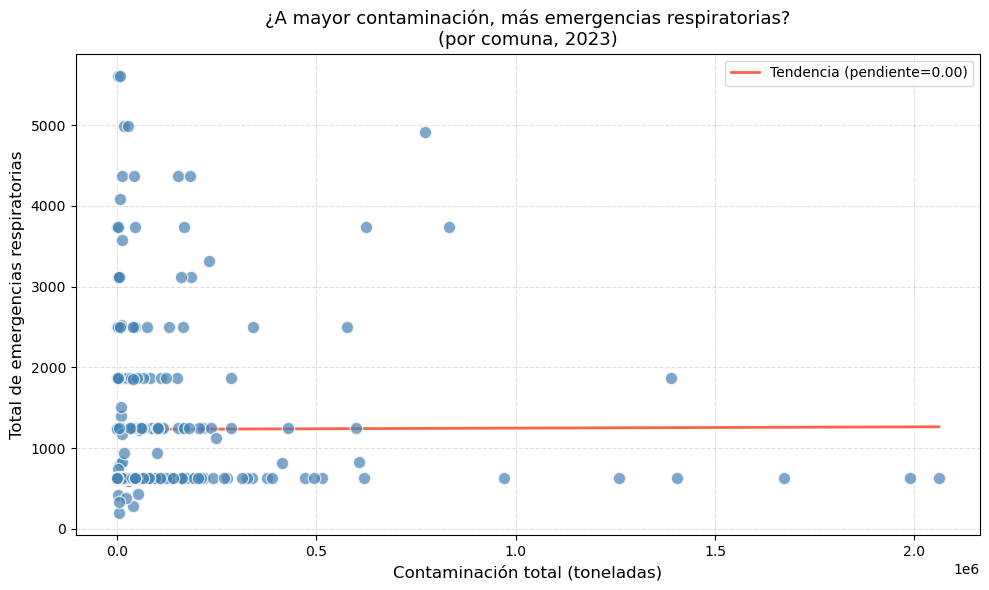

Correlación de Pearson: 0.004


In [13]:
import numpy as np

# Eliminar el punto más alejado (mayor contaminación)
outlier = union['cantidad_total_toneladas'].idxmax()
union_plot = union.drop(index=outlier)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    union_plot['cantidad_total_toneladas'],
    union_plot['total_emergencias'],
    color='steelblue', alpha=0.7, edgecolors='white', s=80, zorder=3
)

# Línea de tendencia
m, b = np.polyfit(union_plot['cantidad_total_toneladas'], union_plot['total_emergencias'], 1)
x_line = np.linspace(union_plot['cantidad_total_toneladas'].min(), union_plot['cantidad_total_toneladas'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label=f'Tendencia (pendiente={m:.2f})')



ax.set_xlabel('Contaminación total (toneladas)', fontsize=12)
ax.set_ylabel('Total de emergencias respiratorias', fontsize=12)
ax.set_title('¿A mayor contaminación, más emergencias respiratorias?\n(por comuna, 2023)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr = union_plot['cantidad_total_toneladas'].corr(union_plot['total_emergencias'])
print(f"Correlación de Pearson: {corr:.3f}")


<BarContainer object of 10 artists>

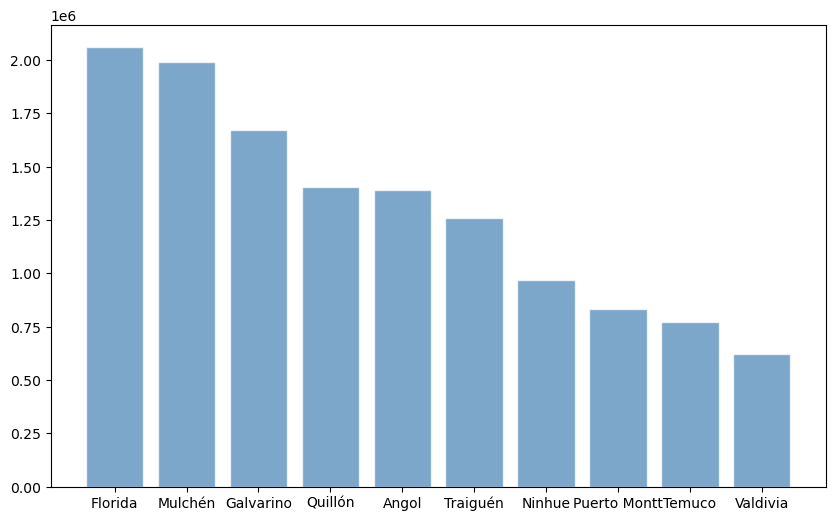

In [16]:
top10 = union_plot.sort_values('cantidad_total_toneladas', ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10['cantidad_total_toneladas'], color='steelblue', alpha=0.7, edgecolor='white')


<BarContainer object of 10 artists>

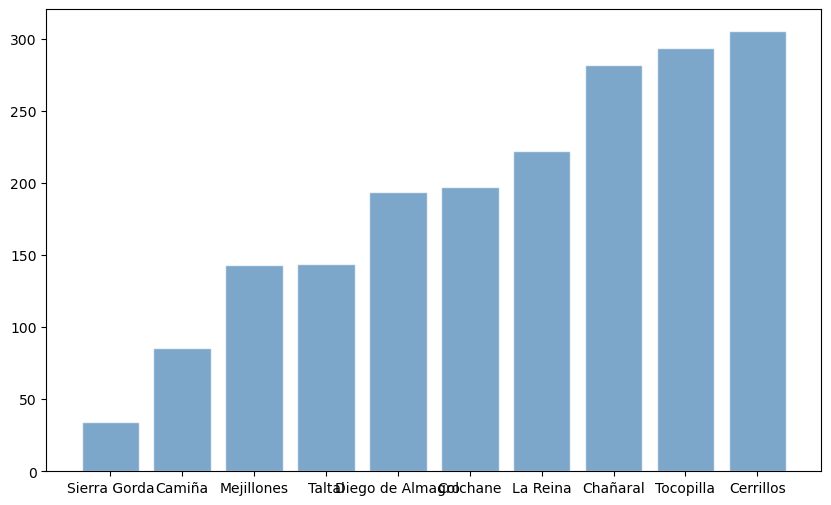

In [17]:
ultimos10 = union_plot.sort_values('cantidad_total_toneladas', ascending=True).head(10)
plt.figure(figsize=(10, 6))
plt.bar(ultimos10.index, ultimos10['cantidad_total_toneladas'], color='steelblue', alpha=0.7, edgecolor='white')

<BarContainer object of 10 artists>

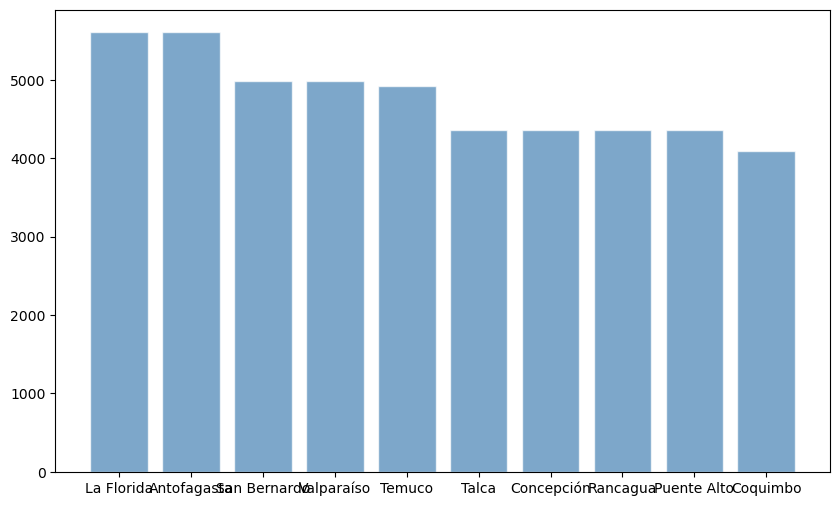

In [18]:
top10_emergencias = union_plot.sort_values('total_emergencias', ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10_emergencias.index, top10_emergencias['total_emergencias'], color='steelblue', alpha=0.7, edgecolor='white')

<BarContainer object of 10 artists>

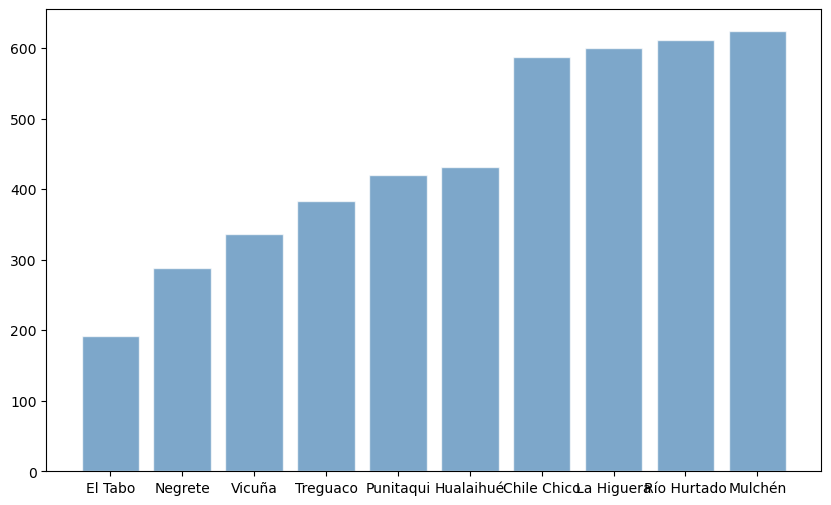

In [19]:
ultimos10_emergencias = union_plot.sort_values('total_emergencias', ascending=True).head(10)
plt.figure(figsize=(10, 6))
plt.bar(ultimos10_emergencias.index, ultimos10_emergencias['total_emergencias'], color='steelblue', alpha=0.7, edgecolor='white')